# Segmentation Olist — 01 Analyse Exploratoire

**Objectif :** Explorer les 9 tables du dataset Olist pour comprendre
la structure des données, identifier les valeurs manquantes,
les distributions et préparer le feature engineering RFM.

- **Input :** `data/raw/*.csv`
- **Output :** `data/processed/rfm_features.csv`

**Plan :**
1. Chargement des données
2. Vue d'ensemble (shape, types, valeurs manquantes)
3. Analyse univariée (distributions)
4. Analyse temporelle (évolution des commandes)
5. Analyse géographique
6. Corrélations et relations entre variables
7. Conclusions pour le feature engineering

### Répertoire de travail

In [3]:
import os
from pathlib import Path

# Se placer à la racine du projet quel que soit l'endroit d'où le notebook est lancé
PROJECT_ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path.cwd().parent
os.chdir(PROJECT_ROOT)

print(f"Répertoire de travail : {os.getcwd()}")

Répertoire de travail : c:\Users\stg_ly84525\Desktop\olist-customer-segmentation


### Imports

In [4]:
# Stdlib
import os
import warnings
warnings.filterwarnings("ignore")

# Data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Config affichage
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print("Imports OK")

pandas  : 2.3.3
numpy   : 2.4.3
Imports OK


### Chargement des données

In [5]:
from src.data.load_data import load_olist

dfs = load_olist("data/raw")

OK orders                      99441 lignes x  8 colonnes
OK order_items                112650 lignes x  7 colonnes
OK order_payments             103886 lignes x  5 colonnes
OK order_reviews               99224 lignes x  7 colonnes
OK customers                   99441 lignes x  5 colonnes


### Vue d'ensemble de chaque table

In [6]:
# Vue d'ensemble de chaque table
for name, df in dfs.items():
    print(f"\n{'='*50}")
    print(f"TABLE : {name.upper()}")
    print(f"{'='*50}")
    print(f"Shape        : {df.shape}")
    print(f"Colonnes     : {list(df.columns)}")
    print(f"Types        :\n{df.dtypes}")
    print(f"\nValeurs manquantes :")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.any() else "  Aucune")


TABLE : ORDERS
Shape        : (99441, 8)
Colonnes     : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Types        :
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Valeurs manquantes :
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

TABLE : ORDER_ITEMS
Shape        : (112650, 7)
Colonnes     : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Types        :
order_id                object
order_item_id            int64
product_

### Résumé des valeurs manquantes

In [7]:
print("RÉSUMÉ VALEURS MANQUANTES\n")
print(f"{'Table':<20} {'Colonnes avec NaN':<25} {'% lignes affectées'}")
print("-" * 60)

for name, df in dfs.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        for col, count in missing.items():
            pct = count / len(df) * 100
            print(f"{name:<20} {col:<25} {pct:.1f}%")
    else:
        print(f"{name:<20} {'Aucune':<25} 0%")

RÉSUMÉ VALEURS MANQUANTES

Table                Colonnes avec NaN         % lignes affectées
------------------------------------------------------------
orders               order_approved_at         0.2%
orders               order_delivered_carrier_date 1.8%
orders               order_delivered_customer_date 3.0%
order_items          Aucune                    0%
order_payments       Aucune                    0%
order_reviews        review_comment_title      88.3%
order_reviews        review_comment_message    58.7%
customers            Aucune                    0%


### Distribution des statuts de commandes

In [9]:
print("Distribution des statuts de commandes :")
print(dfs["orders"]["order_status"].value_counts())
print(f"\nTotal : {len(dfs['orders'])} commandes")

Distribution des statuts de commandes :
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total : 99441 commandes


### Nettoyage et conversion des dates

In [10]:
# Filtrer uniquement les commandes livrées
orders_clean = dfs["orders"][
    dfs["orders"]["order_status"] == "delivered"
].copy()

print(f"Commandes totales   : {len(dfs['orders'])}")
print(f"Commandes livrées   : {len(orders_clean)}")
print(f"Commandes exclues   : {len(dfs['orders']) - len(orders_clean)}")

# Convertir les colonnes dates en datetime
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

print(f"\nTypes après conversion :")
print(orders_clean[date_cols].dtypes)

Commandes totales   : 99441
Commandes livrées   : 96478
Commandes exclues   : 2963

Types après conversion :
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


### Analyse temporelle

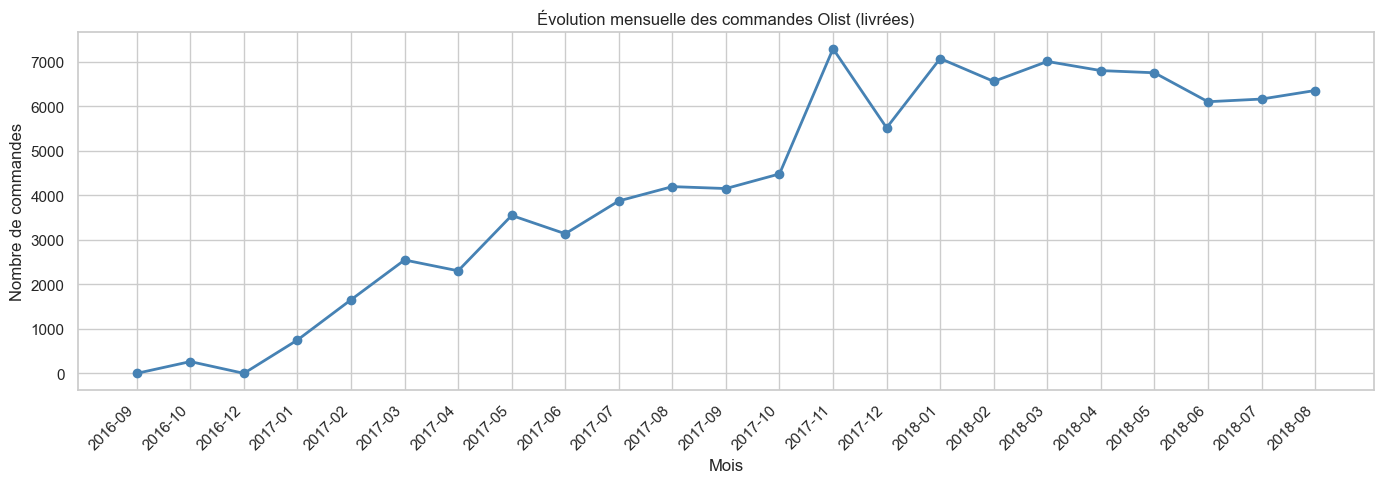


Période couverte : 2016-09-15
                   2018-08-29


In [11]:
# Extraire le mois/année de chaque commande
orders_clean["purchase_month"] = (
    orders_clean["order_purchase_timestamp"].dt.to_period("M")
)

# Évolution mensuelle du volume de commandes
monthly = (
    orders_clean
    .groupby("purchase_month")
    .size()
    .reset_index(name="nb_orders")
)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly["purchase_month"].astype(str),
    monthly["nb_orders"],
    marker="o",
    linewidth=2,
    color="steelblue"
)
plt.xticks(rotation=45, ha="right")
plt.title("Évolution mensuelle des commandes Olist (livrées)")
plt.xlabel("Mois")
plt.ylabel("Nombre de commandes")
plt.tight_layout()
plt.show()

print(f"\nPériode couverte : {orders_clean['order_purchase_timestamp'].min().date()}")
print(f"                   {orders_clean['order_purchase_timestamp'].max().date()}")

### Vérification de la date de référence 

In [12]:
# Date de référence pour le calcul de la Récence
# = lendemain de la dernière commande du dataset
SNAPSHOT_DATE = pd.Timestamp("2018-09-01")

print(f"Dernière commande    : {orders_clean['order_purchase_timestamp'].max().date()}")
print(f"Date de référence    : {SNAPSHOT_DATE.date()}")
print(f"Période analysée     : {orders_clean['order_purchase_timestamp'].min().date()} "
      f"→ {orders_clean['order_purchase_timestamp'].max().date()}")

Dernière commande    : 2018-08-29
Date de référence    : 2018-09-01
Période analysée     : 2016-09-15 → 2018-08-29


### Distribution des montants

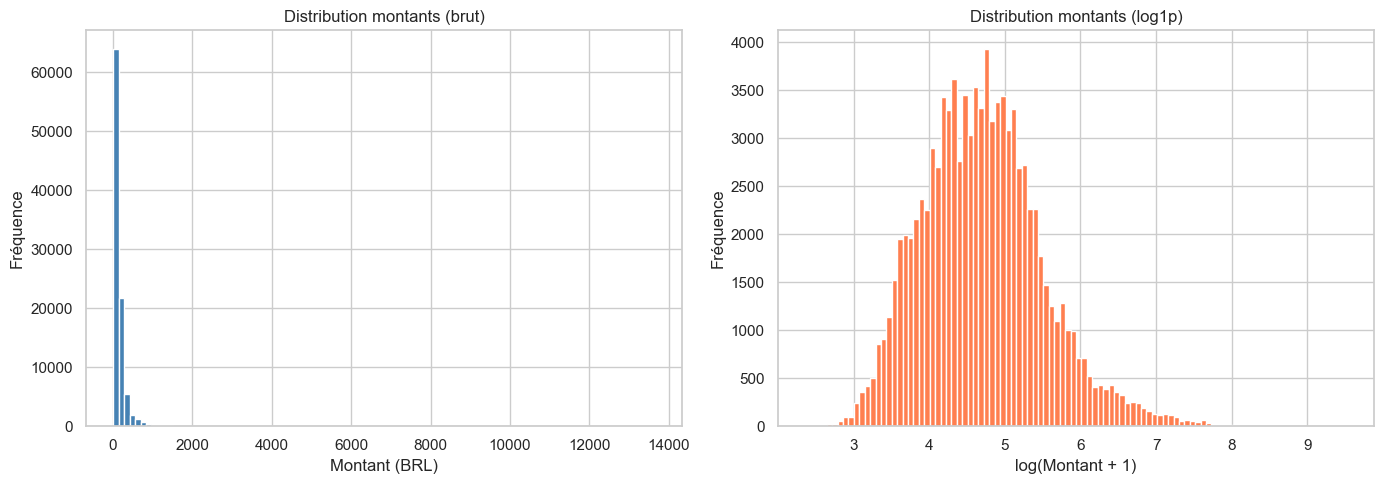


Statistiques montants par commande (BRL) :
count   96478.00
mean      159.83
std       218.79
min         9.59
25%        61.85
50%       105.28
75%       176.26
max     13664.08
Name: order_value, dtype: float64


In [13]:
# Merge orders_clean avec order_items pour avoir les montants
df_items = dfs["order_items"].copy()

orders_amounts = orders_clean.merge(
    df_items[["order_id", "price", "freight_value"]],
    on="order_id",
    how="left"
)

# Montant total par commande (prix + frais de port)
orders_amounts["total_amount"] = (
    orders_amounts["price"] + orders_amounts["freight_value"]
)

# Agrégation par commande
order_value = (
    orders_amounts
    .groupby("order_id")["total_amount"]
    .sum()
    .reset_index(name="order_value")
)

# Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avant log-transformation
axes[0].hist(order_value["order_value"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution montants (brut)")
axes[0].set_xlabel("Montant (BRL)")
axes[0].set_ylabel("Fréquence")

# Après log-transformation
axes[1].hist(
    np.log1p(order_value["order_value"]),
    bins=100,
    color="coral",
    edgecolor="white"
)
axes[1].set_title("Distribution montants (log1p)")
axes[1].set_xlabel("log(Montant + 1)")
axes[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

# Statistiques descriptives
print("\nStatistiques montants par commande (BRL) :")
print(order_value["order_value"].describe().round(2))

### Analyse de la fréquence d'achat

In [14]:
# Nombre de commandes par client unique
customer_orders = (
    orders_clean
    .merge(dfs["customers"][["customer_id", "customer_unique_id"]], on="customer_id")
    .groupby("customer_unique_id")
    .size()
    .reset_index(name="nb_orders")
)

print("Distribution fréquence d'achat par client :")
print(customer_orders["nb_orders"].value_counts().head(10))
print(f"\nClients avec 1 seule commande  : "
      f"{(customer_orders['nb_orders'] == 1).sum()} "
      f"({(customer_orders['nb_orders'] == 1).mean()*100:.1f}%)")
print(f"Clients avec 2+ commandes      : "
      f"{(customer_orders['nb_orders'] > 1).sum()} "
      f"({(customer_orders['nb_orders'] > 1).mean()*100:.1f}%)")
print(f"\nMax commandes par client       : {customer_orders['nb_orders'].max()}")
print(f"Moyenne commandes par client   : {customer_orders['nb_orders'].mean():.2f}")

Distribution fréquence d'achat par client :
nb_orders
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

Clients avec 1 seule commande  : 90557 (97.0%)
Clients avec 2+ commandes      : 2801 (3.0%)

Max commandes par client       : 15
Moyenne commandes par client   : 1.03


### Analyse de la satisfaction

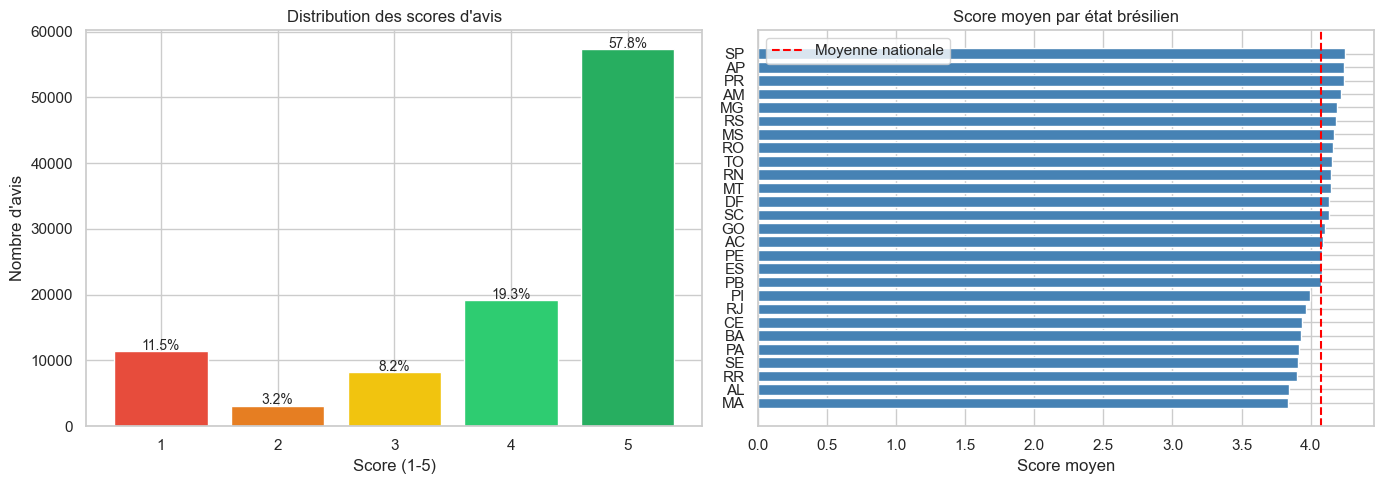


Statistiques scores d'avis :
count   99224.00
mean        4.09
std         1.35
min         1.00
25%         4.00
50%         5.00
75%         5.00
max         5.00
Name: review_score, dtype: float64

Score moyen national : 4.09


In [15]:
# Distribution des notes d'avis
reviews = dfs["order_reviews"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des scores
score_counts = reviews["review_score"].value_counts().sort_index()
axes[0].bar(
    score_counts.index,
    score_counts.values,
    color=["#e74c3c","#e67e22","#f1c40f","#2ecc71","#27ae60"],
    edgecolor="white"
)
axes[0].set_title("Distribution des scores d'avis")
axes[0].set_xlabel("Score (1-5)")
axes[0].set_ylabel("Nombre d'avis")
for i, (score, count) in enumerate(score_counts.items()):
    pct = count / len(reviews) * 100
    axes[0].text(score, count + 200, f"{pct:.1f}%", ha="center", fontsize=10)

# Score moyen par état
customers_reviews = (
    orders_clean
    .merge(dfs["customers"][["customer_id", "customer_unique_id",
                              "customer_state"]], on="customer_id")
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
)
state_scores = (
    customers_reviews
    .groupby("customer_state")["review_score"]
    .mean()
    .sort_values()
)
axes[1].barh(state_scores.index, state_scores.values, color="steelblue")
axes[1].set_title("Score moyen par état brésilien")
axes[1].set_xlabel("Score moyen")
axes[1].axvline(x=state_scores.mean(), color="red",
                linestyle="--", label="Moyenne nationale")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nStatistiques scores d'avis :")
print(reviews["review_score"].describe().round(2))
print(f"\nScore moyen national : {reviews['review_score'].mean():.2f}")

### Analyse du délai de livraison

Statistiques délai de livraison (jours) :
count   96470.00
mean      -11.88
std        10.18
min      -147.00
25%       -17.00
50%       -12.00
75%        -7.00
max       188.00
Name: delivery_delay_days, dtype: float64

Commandes en retard  : 6534 (6.8%)
Commandes en avance  : 88644 (91.9%)


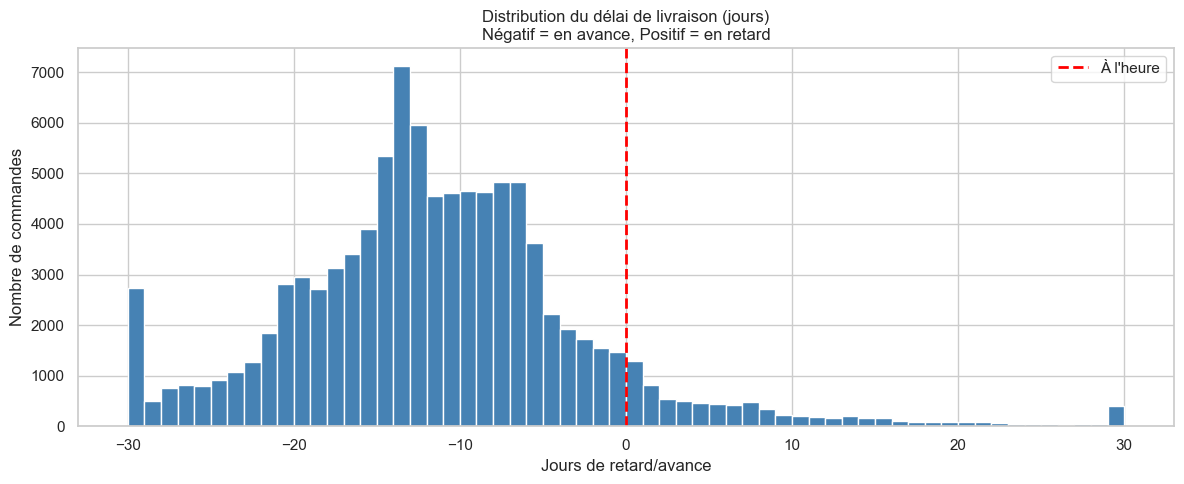

In [16]:
# Calculer le délai réel vs estimé
orders_clean["delivery_delay_days"] = (
    orders_clean["order_delivered_customer_date"] -
    orders_clean["order_estimated_delivery_date"]
).dt.days

# Positif = livré en retard, Négatif = livré en avance
print("Statistiques délai de livraison (jours) :")
print(orders_clean["delivery_delay_days"].describe().round(2))
print(f"\nCommandes en retard  : "
      f"{(orders_clean['delivery_delay_days'] > 0).sum()} "
      f"({(orders_clean['delivery_delay_days'] > 0).mean()*100:.1f}%)")
print(f"Commandes en avance  : "
      f"{(orders_clean['delivery_delay_days'] < 0).sum()} "
      f"({(orders_clean['delivery_delay_days'] < 0).mean()*100:.1f}%)")

# Distribution
plt.figure(figsize=(12, 5))
plt.hist(
    orders_clean["delivery_delay_days"].clip(-30, 30),
    bins=60,
    color="steelblue",
    edgecolor="white"
)
plt.axvline(x=0, color="red", linestyle="--", linewidth=2, label="À l'heure")
plt.title("Distribution du délai de livraison (jours)\n"
          "Négatif = en avance, Positif = en retard")
plt.xlabel("Jours de retard/avance")
plt.ylabel("Nombre de commandes")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusions EDA — Décisions pour le feature engineering

#### Observations clés
1. **97% des clients** n'ont qu'une seule commande
   → La Fréquence seule n'est pas discriminante
   → On enrichit le RFM avec satisfaction et délai

2. **Distribution montants asymétrique** (mean=160, max=13664 BRL)
   → Log-transformation obligatoire avant clustering

3. **92% des livraisons en avance** (moyenne -12 jours)
   → Outliers à clipper entre -30 et +30 jours

4. **Score moyen 4.09/5** avec distribution bimodale
   → Feature utile — clients satisfaits vs insatisfaits distincts

5. **Période : sept 2016 → août 2018**
   → Date de référence RFM : 2018-09-01

#### Features retenues
| Feature | Calcul | Transformation |
|---|---|---|
| recency | jours depuis dernier achat | aucune |
| frequency | nb commandes | log1p |
| monetary | montant total | log1p |
| review_score | moyenne des notes | aucune |
| delivery_delay | jours réel - estimé | clip(-30,30) |

#### Prochaine étape
→ `segmentation_02_modeling.ipynb` : feature engineering + clustering